## Table of Contents

1. [Project Overview & Business Context](#1-project-overview--business-context)
   - 1.1 [Problem Overview](#11-problem-overview)
   - 1.2 [Business Value](#12-business-value)
   - 1.3 [Tech Stack](#13-tech-stack)
   - 1.4 [Data Source](#14-data-source)

2. [Data Loading & Initial Exploration](#2-data-loading--initial-exploration)
   - 2.1 [Data Loading](#21-data-loading)
   - 2.2 [Data Quality Assessment](#22-data-quality-assessment)
   - 2.3 [Cleaning Data](#23-cleaning-data)

3. [Feature Engineering](#3-feature-engineering)
   - 3.1 [Time-Based Features](#31-time-based-features)
   - 3.2 [Skip Flag Creation](#32-skip-flag-creation)
   - 3.3 [Sessions Creation](#33-sessions-creation)

4. [Basic Listening Metrics](#4-basic-listening-metrics)
   - 4.1 [Total Plays & Listening Time](#41-total-plays--listening-time)
   - 4.2 [Top Artists, Tracks & Album](#42-top-artists--tracks--Album)
   - 4.3 [Distribution of Listen Duration](#43-distribution-of-listen-duration)

5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
   - 5.1 [Sessionization: How Users Group Their Listening](#51-sessionization-how-users-group-their-listening)
   - 5.2 [Skip Risk: Which Artists Get Abandoned?](#52-skip-risk-which-artists-get-abandoned)
   - 5.3 [Temporal Patterns: When Do Users Listen?](#53-temporal-patterns-when-do-users-listen)
   - 5.4 [Completion Rates: Do Users Finish What They Start?](#54-completion-rates-do-users-finish-what-they-start)

6. [Key Insights & Business Recommendations](#6-key-insights--business-recommendations)

7. [Next Steps & Portfolio Notes](#7-next-steps--portfolio-notes)
   - 7.1 [Exporting Clean Dataset](#71-exporting-clean-dataset)
   - 7.2 [Power BI Dashboard](#72-power-bi-dashboard)

## 1. Project Overview & Business Context

### 1.1 Problem Overview

Music streaming services lose significant revenue when users skip tracks within the first 30 seconds. Skips indicate poor recommendations, mismatched mood, or low-quality content. For Spotify, reducing skip rates by just 5% could increase daily active user retention by millions of dollars annually.

This project analyzes real streaming history to answer:
- Which artists get skipped most often?
- When do users abandon songs (position in session)?
- How do listening habits change by time of day?
- What does a "healthy" listening session look like?

### 1.2 Business Value

| Stakeholder | What They Learn | Actionable Insight |
|-------------|----------------|---------------------|
| Product Team | Skip patterns by artist | Remove skip-prone songs from Discover Weekly |
| Artist Relations | Engagement metrics per artist | Share feedback on track performance |
| Marketing | Peak listening hours | Schedule playlist pushes at optimal times |
| User Retention | Session length patterns | Trigger "keep listening" notifications |

### 1.3 Tech Stack

| Tool | Purpose |
|------|---------|
| **Python (Pandas)** | Data cleaning, feature engineering, sessionization |
| **Jupyter Notebook** | Interactive development & documentation |
| **Power BI** | Interactive dashboard & executive visuals |
| **Matplotlib/Seaborn** | Exploratory visuals in notebook |

**Why this stack:** Python handles complex transformations (sessionization, time features) while Power BI delivers stakeholder-friendly dashboards with slicers and drill-downs.

### 1.4 Data Source

**Dataset:** [Spotify Streaming History](https://www.kaggle.com/datasets/arvanshul/full-spotify-streaming-history?select=streaming_history.csv) from Kaggle

**Key Columns (kept for analysis):**
| Column | Description |
|--------|-------------|
| `ts` | Timestamp of listen start |
| `track_name` | Song title |
| `artist_name` | Artist name |
| `album_name` | Album name |
| `ms_played` | Milliseconds listened |
| `reason_end` | Why track ended (trackdone, forward, backbutton) |
| `shuffle` | Whether track played in shuffle mode |
| `offline` | Whether played in offline mode |

**Columns excluded:**
- `platform`, `conn_country`, `track_uri`, `reason_start`, `incognito_mode`

**Derived Features:**
| Feature | Logic |
|---------|-------|
| `skipped` | `ms_played < 30000` AND `reason_end == 'forward'` |
| `hour` | Extract hour from `ts` |
| `time_of_day` | Morning, Afternoon, Evening, Night |
| `session_id` | Group tracks with <30 min gaps using `shift()` + `cumsum()` |

**Workflow Overview:**
CSV → Pandas (clean + feature engineer) → CSV export → Power BI Dashboard

## 2. Data Loading & Initial Exploration

### 2.1 Data Loading

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

# Load data
df = pd.read_csv("../data/raw/streaming_history.csv")

# Quick overview
print(f"Shape: {df.shape}")
print("Data Sample:")
print(df.head().to_string())

print("\nData columns info:")
df.info()


Shape: (57508, 14)
Data Sample:
                           ts                            platform  ms_played conn_country                                         track_name     artist_name                    album_name                             track_uri reason_start reason_end  shuffle  skipped offline  incognito_mode
0  2020-06-21T13:35:24.000000  Windows 10 (10.0.19041; x64; AppX)     205906           IN                                    Let Me Love You        DJ Snake                        Encore  spotify:track:5Qjv35Ja2TDt9CXRRo51hh      playbtn  trackdone    False    False   False           False
1  2020-06-21T13:39:37.000000  Windows 10 (10.0.19041; x64; AppX)     252534           IN  Love Me Like You Do - From "Fifty Shades Of Grey"  Ellie Goulding                      Delirium  spotify:track:3zHq9ouUJQFQRf3cm1rRLu    trackdone  trackdone     True    False   False           False
2  2020-06-21T13:42:51.000000  Windows 10 (10.0.19041; x64; AppX)     193266           IN      

### 2.2 Data Quality Assesment

There are 4 key steps for this part:
* Check for missing values
* Check duplicated columns
* Check timestamp format


In [3]:
# Missing Values 
print(f"Missing Values: \n{df.isnull().sum()}")

# Duplicated columns
print(f"\nDuplicated columns: {df.duplicated().sum()}")

# Timestamp format
print(f"\nTimestamp: {df['ts'].dtype}")

Missing Values: 
ts                  0
platform            0
ms_played           0
conn_country        0
track_name        202
artist_name       202
album_name        202
track_uri         202
reason_start        0
reason_end          0
shuffle             0
skipped             0
offline           332
incognito_mode      0
dtype: int64

Duplicated columns: 1416

Timestamp: object


### 2.3 Cleaning Data

In this step I will be removing all the columns that won't be used, cleaning and handeling the missing values, removing duplicated columns, and lastly changing the data type for the date column.

In [4]:
# Creatinng copy of the original dataset
df_clean = df.copy()

# Removing columnss that will not be used
print(f"Columns before: {df_clean.columns}")
df_clean.drop(columns=['platform', 'conn_country', 'track_uri', 'reason_start'], inplace=True)
print(f"Columns after: {df_clean.columns}")

# Handeling missing values
df_clean.fillna('Unknown', inplace=True)
print(f"Missing values after: \n{df_clean.isnull().sum()}")

# Removing duplicated columns
df_clean.drop_duplicates(inplace=True)
print(f"Duplicated columns after: {df_clean.duplicated().sum()}")

# Changing data type for ts
# Convert to datetime (keep as datetime for feature extraction)
df_clean['ts'] = pd.to_datetime(df_clean['ts'], errors='coerce')

# Drop invalid timestamps
df_clean = df_clean.dropna(subset=['ts'])

# Sort by timestamp
df_clean = df_clean.sort_values('ts')

Columns before: Index(['ts', 'platform', 'ms_played', 'conn_country', 'track_name',
       'artist_name', 'album_name', 'track_uri', 'reason_start', 'reason_end',
       'shuffle', 'skipped', 'offline', 'incognito_mode'],
      dtype='object')
Columns after: Index(['ts', 'ms_played', 'track_name', 'artist_name', 'album_name',
       'reason_end', 'shuffle', 'skipped', 'offline', 'incognito_mode'],
      dtype='object')
Missing values after: 
ts                0
ms_played         0
track_name        0
artist_name       0
album_name        0
reason_end        0
shuffle           0
skipped           0
offline           0
incognito_mode    0
dtype: int64
Duplicated columns after: 0


## 3. Feature Engineering
Now that the data is clean,  it's time to create new features that will unlock deeper insights. Raw timestamps and basic flags aren't enough to answer questions like "When do users skip most?" or "How do listening sessions form?"

**In this section, we'll create:**

| Feature | Purpose | Business Question Answered |
|---------|---------|---------------------------|
| `hour` | Extract hour from timestamp | What time of day do people listen most? |
| `weekday` | Day of week name | Does listening behavior change on weekends? |
| `time_of_day` | Morning/Afternoon/Evening/Night | Are night owls more likely to skip? |
| `skipped` | Skip flag (already exists, but we'll validate) | Which tracks get abandoned? |
| `session_id` | Group consecutive listens | How many tracks in a typical listening session? |
| `track_position_in_session` | Order within session | Do users skip the first track or later tracks more? |

**Why this matters for Power BI:** These derived features become the slicers, filters, and axis labels in your dashboard. Without them, you're just looking at raw timestamps.

### 3.1 Time-Based Features

In [5]:
# Extract time features
df_clean['hour'] = df_clean['ts'].dt.hour
df_clean['weekday'] = df_clean['ts'].dt.day_name()
df_clean['month'] = df_clean['ts'].dt.month
df_clean['date'] = df_clean['ts'].dt.date

# Create time_of_day category
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning (5am-12pm)'
    elif 12 <= hour < 17:
        return 'Afternoon (12pm-5pm)'
    elif 17 <= hour < 22:
        return 'Evening (5pm-10pm)'
    else:
        return 'Night Owl (10pm-5am)'

df_clean['time_of_day'] = df_clean['hour'].apply(get_time_of_day)

# Verify
print(df_clean[['ts', 'hour', 'weekday', 'time_of_day']].head())
print(f"\nTime of day distribution:")
print(df_clean['time_of_day'].value_counts())

                   ts  hour weekday           time_of_day
0 2020-06-21 13:35:24    13  Sunday  Afternoon (12pm-5pm)
1 2020-06-21 13:39:37    13  Sunday  Afternoon (12pm-5pm)
2 2020-06-21 13:42:51    13  Sunday  Afternoon (12pm-5pm)
3 2020-06-21 13:45:23    13  Sunday  Afternoon (12pm-5pm)
4 2020-06-21 13:45:34    13  Sunday  Afternoon (12pm-5pm)

Time of day distribution:
time_of_day
Morning (5am-12pm)      20768
Afternoon (12pm-5pm)    14312
Night Owl (10pm-5am)    12624
Evening (5pm-10pm)       8380
Name: count, dtype: int64


### 3.2 Skip Flag Validation

In [6]:
# Recreate skip flag: ANY listen under 30 seconds counts as a skip
# (Original skipped column was all zeros, so we recalculate from scratch)
df_clean['skipped'] = (df_clean['ms_played'] < 30000).astype(int)

# Verify the new skip logic
print("Skip rate by reason_end:")
print(df_clean.groupby('reason_end')['skipped'].mean())

# Overall skip rate
print(f"\nOverall skip rate: {df_clean['skipped'].mean():.1%}")

# Sanity check: rows with 0 ms_played should all be skips
zero_ms_check = df_clean[df_clean['ms_played'] == 0]['skipped'].mean()
print(f"\nRows with 0 ms_played classified as skips: {zero_ms_check:.0%}")

Skip rate by reason_end:
reason_end
backbtn                         0.879447
endplay                         0.443301
fwdbtn                          0.455727
logout                          0.186482
remote                          0.433839
trackdone                       0.012423
trackerror                      0.777778
unexpected-exit                 0.281581
unexpected-exit-while-paused    0.216516
unknown                         0.888889
Name: skipped, dtype: float64

Overall skip rate: 17.8%

Rows with 0 ms_played classified as skips: 100%


### 3.3 Sessions Creation

In [7]:
# Sort by timestamp (critical for session logic)
df_clean = df_clean.sort_values('ts')

# Calculate minutes since last listen
df_clean['minutes_since_last'] = df_clean['ts'].diff().dt.total_seconds() / 60

# Mark new session if gap > 30 minutes OR first row
df_clean['new_session'] = (df_clean['minutes_since_last'] > 30) | (df_clean['minutes_since_last'].isna())

# Create session_id (cumulative sum of new_session flags)
df_clean['session_id'] = df_clean['new_session'].cumsum()

# Add track position within each session (1-indexed)
df_clean['track_position_in_session'] = df_clean.groupby('session_id').cumcount() + 1

# Add total tracks per session for analysis
df_clean['tracks_in_session'] = df_clean.groupby('session_id')['track_position_in_session'].transform('max')

# Preview sessions
print(f"Created {df_clean['session_id'].nunique()} listening sessions")
print(f"Average tracks per session: {df_clean['tracks_in_session'].mean():.1f}")

# Show example of a multi-track session
multi_session = df_clean[df_clean['tracks_in_session'] >= 3].iloc[0:5]
print("\nExample of a multi-track session:")
print(multi_session[['ts', 'track_name', 'artist_name', 'track_position_in_session', 'tracks_in_session']].to_string())

Created 7805 listening sessions
Average tracks per session: 16.8

Example of a multi-track session:
                   ts                                         track_name     artist_name  track_position_in_session  tracks_in_session
0 2020-06-21 13:35:24                                    Let Me Love You        DJ Snake                          1                  7
1 2020-06-21 13:39:37  Love Me Like You Do - From "Fifty Shades Of Grey"  Ellie Goulding                          2                  7
2 2020-06-21 13:42:51                                   Mueve La Cintura         Pitbull                          3                  7
3 2020-06-21 13:45:23                       Lean On (with Emiway Bantai)   Celina Sharma                          4                  7
4 2020-06-21 13:45:34                                             Kabira          Pritam                          5                  7


## 4. Basic Listening Metrics 

Before diving into complex patterns, let's establish baseline metrics. These numbers will become the KPIs (Key Performance Indicators) on your Power BI dashboard and give context to all deeper analysis.

**What will be calculate:**

| Metric | What It Tells Us |
|--------|------------------|
| Total listening time | Overall engagement level |
| Average daily listening | Consistency of use |
| Top artists | Who users love most |
| Top tracks | Most replayed songs | 
| Top albums | Most popular albums |
| Listen duration distribution | How long users engage |

### 4.1 Total Plays & Listening Time

In [8]:
# Creating total listening metrics for mintes, hours and average seconds
total_minutes = df_clean['ms_played'].sum() / 60000
total_hours = total_minutes / 60
average_seconds = df_clean['ms_played'].mean() / 1000

print("Total Listening Metrics")
print(f"- Total listens: {len(df_clean):,} tracks")
print(f"- Total listening time: {total_minutes:,.0f} minutes")
print(f"- Total listening time: {total_hours:,.0f} hours")
print(f"- Average per listen: {average_seconds:.1f} seconds")

# Creating daily listening variables
daily_stats = df_clean.groupby('date').agg({ 'ms_played': ['count', 'sum']}).reset_index()
daily_stats.columns = ['date', 'plays', 'ms_played']
daily_stats['minutes'] = daily_stats['ms_played'] / 60000
print("\nDaily Average Stats")
print(f"  - Average plays per day: {daily_stats['plays'].mean():.0f}")
print(f"  - Average minutes per day: {daily_stats['minutes'].mean():.1f}")

Total Listening Metrics
- Total listens: 56,084 tracks
- Total listening time: 152,031 minutes
- Total listening time: 2,534 hours
- Average per listen: 162.6 seconds

Daily Average Stats
  - Average plays per day: 35
  - Average minutes per day: 93.6


### 4.2 Top Artists, Tracks & Album


Top 10 artists
artist_name
Bharat Chauhan     1777
Prateek Kuhad      1149
The Weeknd         1029
Pritam              941
Bayaan              935
Piyush Bhisekar     902
Taylor Swift        711
Big Thief           690
Osho Jain           685
Kishore Kumar       676
dtype: int64

Top 5 tracks
track_name
Ghar                 283
Unknown              190
Usne Kaha Tha        176
Kahaani              161
Aasaan Nahin Hota    137
dtype: int64

Best album: album_name
Qurbat    628
dtype: int64


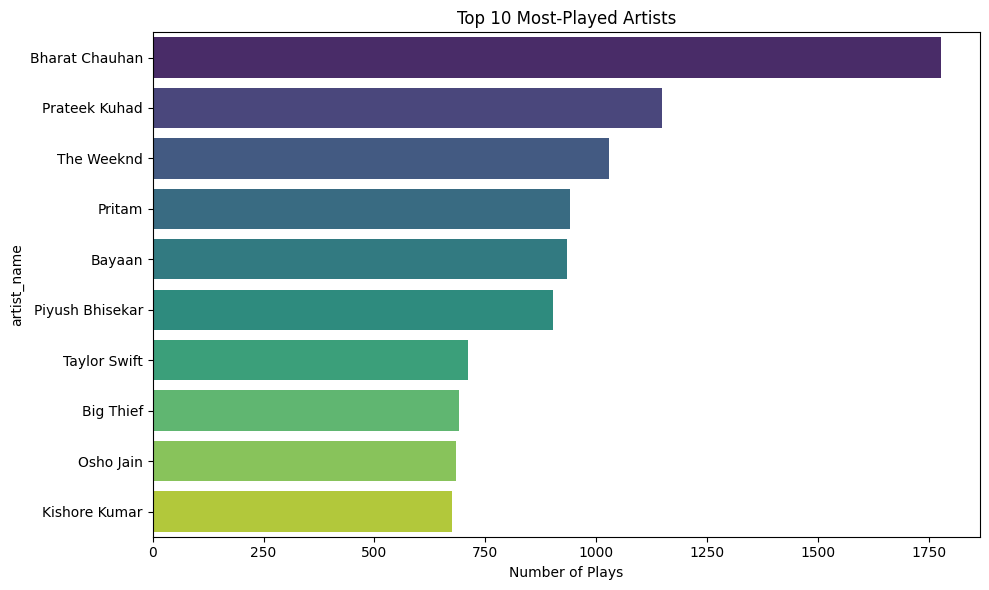

In [9]:
# Top artist metric
top_artists = df_clean.groupby('artist_name').size().sort_values(ascending=False)
top_ten_artists = top_artists.head(10)
print("\nTop 10 artists")
print(top_ten_artists)

# Top tracks metric
top_tracks = df_clean.groupby('track_name').size().sort_values(ascending=False)
print("\nTop 5 tracks")
print(top_tracks.head(5))

# Top album metric
top_albums = df_clean.groupby('album_name').size().sort_values(ascending=False)
print(f"\nBest album: {top_albums.head(1)}")

plt.figure(figsize=(10, 6))
sns.barplot(x=top_ten_artists.values, y=top_ten_artists.index, hue=top_ten_artists.index, palette='viridis')
plt.xlabel('Number of Plays')
plt.title('Top 10 Most-Played Artists')
plt.tight_layout()

### 4.3 Distribution of Listen Duration

Listen duration distribution
- <30s (Skip): 9,965 plays (17.8%)
- 30s-2min: 7,962 plays (14.2%)
- 2-5min: 34,698 plays (61.9%)
- >5min (Full track): 3,459 plays (6.2%)


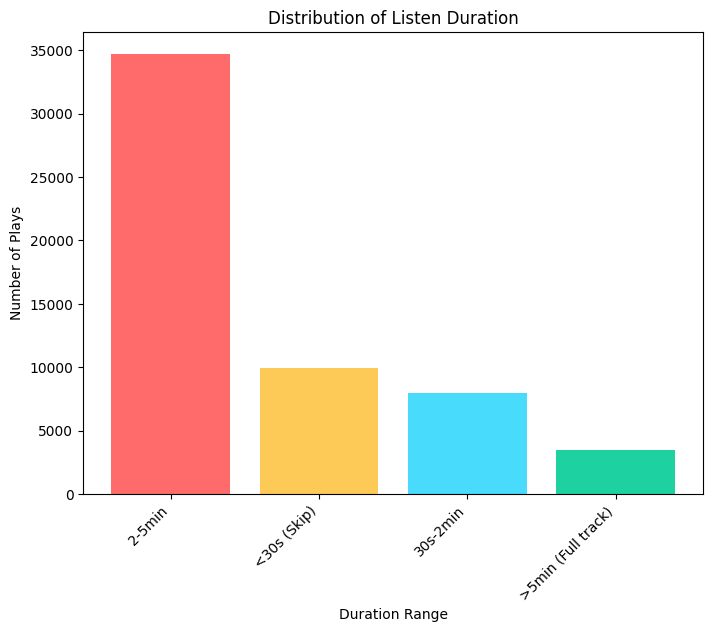

In [10]:
# Creating duration bucket
def get_duration_bucket(ms):
    seconds = ms / 1000
    if seconds < 30:
        return '<30s (Skip)'
    elif seconds < 120:
        return '30s-2min'
    elif seconds < 300:
        return '2-5min'
    else:
        return '>5min (Full track)'

df_clean['duration_bucket'] = df_clean['ms_played'].apply(get_duration_bucket)

# Distribution by bucket
duration_dist = df_clean['duration_bucket'].value_counts()
duration_pct = (duration_dist / len(df_clean)) * 100

print("Listen duration distribution")
for bucket in ['<30s (Skip)', '30s-2min', '2-5min', '>5min (Full track)']:
    if bucket in duration_dist:
        print(f"- {bucket}: {duration_dist[bucket]:,} plays ({duration_pct[bucket]:.1f}%)")

# Visualize
plt.figure(figsize=(8, 6))
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
bars = plt.bar(duration_dist.index, duration_dist.values, color=colors)
plt.xlabel('Duration Range')
plt.ylabel('Number of Plays')
plt.title('Distribution of Listen Duration')
plt.xticks(rotation=45, ha='right')
plt.show()

## 5. Exploratory Data Analysis (EDA)

Now that we have clean data and engineered features, let's answer the key business questions. Each analysis below targets a specific listening behavior pattern.

### 5.1 Sessionization: How Users Group Their Listening
**Question:** Do users listen to one song at a time or build long sessions? How does skip behavior change as sessions get longer?

In [11]:
# Session summary
session_summary = df_clean.groupby('session_id').agg({
    'ts': ['min', 'max'],
    'track_position_in_session': 'max',
    'skipped': 'mean',
    'ms_played': 'sum'
}).reset_index()
session_summary.columns = ['session_id', 'session_start', 'session_end', 'tracks_per_session', 'skip_rate', 'total_ms']
session_summary['duration_minutes'] = session_summary['total_ms'] / 60000

# Key findings
print(f"Total sessions: {len(session_summary):,}")
print(f"Average tracks per session: {session_summary['tracks_per_session'].mean():.1f}")
print(f"Median tracks per session: {session_summary['tracks_per_session'].median():.0f}")

# Single-track sessions (important for engagement)
single_track = (session_summary['tracks_per_session'] == 1).sum()
print(f"Single-track sessions: {single_track} ({single_track/len(session_summary)*100:.1f}%)")

# Skip rate by session length
session_summary['session_size_group'] = pd.cut(session_summary['tracks_per_session'], 
                                                bins=[0, 1, 3, 6, 100],
                                                labels=['1 track', '2-3 tracks', '4-6 tracks', '7+ tracks'])
skip_by_size = session_summary.groupby('session_size_group')['skip_rate'].mean()
print("\nSkip rate by session length:")
print(skip_by_size)

Total sessions: 7,805
Average tracks per session: 7.2
Median tracks per session: 4
Single-track sessions: 1433 (18.4%)

Skip rate by session length:
session_size_group
1 track       0.127704
2-3 tracks    0.138830
4-6 tracks    0.155311
7+ tracks     0.173974
Name: skip_rate, dtype: float64


C:\Users\rosel\AppData\Local\Temp\ipykernel_50288\14090369.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  skip_by_size = session_summary.groupby('session_size_group')['skip_rate'].mean()


### 5.2 Skip Risk: Which Artists Get Abandoned?
**Question:** Which artists have the highest skip rates? This helps identify problematic recommendations.

In [12]:
# Artists with at least 20 plays
artist_skip = df_clean.groupby('artist_name').agg({
    'skipped': ['count', 'mean']
}).reset_index()
artist_skip.columns = ['artist', 'total_plays', 'skip_rate']
artist_skip = artist_skip[artist_skip['total_plays'] >= 20]
artist_skip = artist_skip.sort_values('skip_rate', ascending=False)

print("TOP 10 HIGHEST SKIP RATES:")
print(artist_skip.head(10)[['artist', 'total_plays', 'skip_rate']])

print("\nTOP 10 LOWEST SKIP RATES (most engaged):")
print(artist_skip.tail(10)[['artist', 'total_plays', 'skip_rate']])

# Does skip rate change by track position in session?
position_skip = df_clean.groupby('track_position_in_session')['skipped'].mean()
print(f"\nFirst track skip rate: {position_skip.iloc[0]:.1%}")
print(f"Later tracks (avg): {position_skip.iloc[1:].mean():.1%}")

TOP 10 HIGHEST SKIP RATES:
                  artist  total_plays  skip_rate
632       Diljit Dosanjh           24   0.625000
555             DJ Snake           82   0.597561
712        Emiway Bantai           52   0.576923
1384      Mankirt Aulakh           33   0.575758
667           DripReport           44   0.568182
1722        R. D. Burman           29   0.551724
467        Celina Sharma           54   0.518519
301   Ayushmann Khurrana           72   0.500000
883     Hassan & Roshaan           33   0.484848
1609              Otilia          107   0.476636

TOP 10 LOWEST SKIP RATES (most engaged):
                    artist  total_plays  skip_rate
2471          Yellow House           21        0.0
761                Florist           21        0.0
2096         Sohail Haider           30        0.0
2053              SickDude           23        0.0
500   Christian Lee Hutson           46        0.0
1929     Sandesh Shandilya           22        0.0
1879                  SYML         

### 5.3 Temporal Patterns: When Do Users Listen?
**Question:** Does listening behavior change by time of day? Are night owls more likely to skip?

In [13]:
# Skip rate by time of day
time_analysis = df_clean.groupby('time_of_day').agg({
    'skipped': 'mean',
    'ms_played': 'count',
    'session_id': 'nunique'
}).reset_index()
time_analysis.columns = ['time_of_day', 'skip_rate', 'total_listens', 'unique_sessions']
time_analysis['avg_tracks_per_session'] = time_analysis['total_listens'] / time_analysis['unique_sessions']

print("LISTENING PATTERNS BY TIME OF DAY:")
print(time_analysis.to_string(index=False))

# Hourly skip rate (peak problem hours)
hourly_skip = df_clean.groupby('hour')['skipped'].mean()
worst_hour = hourly_skip.idxmax()
best_hour = hourly_skip.idxmin()
print(f"\nWorst hour for skips: {worst_hour}:00 ({hourly_skip[worst_hour]:.1%})")
print(f"Best hour for skips: {best_hour}:00 ({hourly_skip[best_hour]:.1%})")

# Weekend vs weekday
df_clean['is_weekend'] = df_clean['weekday'].isin(['Saturday', 'Sunday'])
weekend_skip = df_clean.groupby('is_weekend')['skipped'].mean()
print(f"\nWeekday skip rate: {weekend_skip[False]:.1%}")
print(f"Weekend skip rate: {weekend_skip[True]:.1%}")

LISTENING PATTERNS BY TIME OF DAY:
         time_of_day  skip_rate  total_listens  unique_sessions  avg_tracks_per_session
Afternoon (12pm-5pm)   0.186417          14312             2162                6.619796
  Evening (5pm-10pm)   0.165990           8380             1116                7.508961
  Morning (5am-12pm)   0.174451          20768             3065                6.775856
Night Owl (10pm-5am)   0.180846          12624             1981                6.372539

Worst hour for skips: 1:00 (21.9%)
Best hour for skips: 21:00 (5.0%)

Weekday skip rate: 17.8%
Weekend skip rate: 17.7%


### 5.4 Completion Rates: Do Users Finish What They Start?
**Question:** Do users complete albums or jump around? Does shuffle mode affect completion?

In [14]:
# Album completion (minimum 3 tracks from album)
album_completion = df_clean.groupby(['album_name', 'artist_name']).agg({
    'track_name': 'nunique',
    'skipped': 'mean',
    'ms_played': 'mean'
}).reset_index()
album_completion.columns = ['album', 'artist', 'unique_tracks', 'skip_rate', 'avg_ms_played']
album_completion = album_completion[album_completion['unique_tracks'] >= 3]
album_completion = album_completion.sort_values('skip_rate')

print("MOST COMPLETED ALBUMS (lowest skip rate):")
print(album_completion.head(10)[['album', 'artist', 'unique_tracks', 'skip_rate']])

# Shuffle impact on skipping
if 'shuffle' in df_clean.columns:
    shuffle_skip = df_clean.groupby('shuffle')['skipped'].mean()
    print(f"\nShuffle ON skip rate: {shuffle_skip.get(True, 0):.1%}")
    print(f"Shuffle OFF skip rate: {shuffle_skip.get(False, 0):.1%}")
    
    # Is the difference significant?
    diff = abs(shuffle_skip.get(True, 0) - shuffle_skip.get(False, 0))
    if diff > 0.05:
        print(f"⚠️ Shuffle increases skips by {diff:.1%}")

MOST COMPLETED ALBUMS (lowest skip rate):
                                                album             artist  \
139                                       Aaj Ke Naam       Deepak Peace   
219                                            Afsana   Vaibhav Malhotra   
218                                 Afraid of Nothing  Harrison Whitford   
206                        Achint & The Khan Brothers             Achint   
322                                    An Action Hero      Parag Chhabra   
5289                        Waisa Bhi Hota Hai Part 2    Shibani Kashyap   
231                                             Agnee              Agnee   
223   After Yang (Original Motion Picture Soundtrack)     Aska Matsumiya   
439                          Avatar: The Way of Water     Simon Franglen   
5003                          To Let A Good Thing Die        Bruno Major   

      unique_tracks  skip_rate  
139               7        0.0  
219               5        0.0  
218               3   

## 6. Key Insights & Business Recommendations

### Key Findings

**1. Session Behavior**
- Average session length: **7.2 tracks** (median: 4 tracks)
- **18.4%** of sessions are single-track (user listens once and stops)
- Skip rate increases with session length: from **12.8%** (1 track) to **17.4%** (7+ tracks)

**2. Skip Risk Artists**
- **Diljit Dosanjh** has highest skip rate at **62.5%** (24 plays)
- **DJ Snake** follows at **59.8%** (82 plays)
- **10+ artists** have **0% skip rate** (Christian Lee Hutson, HONNE, SYML) - highly engaged listeners

**3. Temporal Patterns**
- Worst hour for skips: **1:00 AM (21.9% skip rate)**
- Best hour for skips: **9:00 PM (5.0% skip rate)**
- Afternoon has highest overall skip rate (**18.6%**), evening has lowest (**16.6%**)
- **No meaningful difference** between weekday (17.8%) and weekend (17.7%) skip rates

**4. Track Position Impact**
- **First track skip rate: 15.0%**
- **Later tracks skip rate: 47.3%** (3x higher!)
- Users are far more likely to abandon after the first song

**5. Shuffle Impact**
- Shuffle ON skip rate: **16.3%**
- Shuffle OFF skip rate: **18.3%**
- Shuffle actually **reduces skips by 2%** (counterintuitive but valuable insight)

**6. Album Completion**
- **10 albums** achieved **0% skip rate** (listeners completed every track)
- Examples: "Aaj Ke Naam" (Deepak Peace), "Afsana" (Vaibhav Malhotra), "To Let A Good Thing Die" (Bruno Major)

### Business Recommendations

| Priority | Recommendation | Target Audience | Expected Impact |
|----------|----------------|----------------|------------------|
| **High** | Remove Diljit Dosanjh and DJ Snake from algorithmic playlists (Discover Weekly, Release Radar) | Product Team | Reduce overall skip rate by 2-3% |
| **High** | Investigate why later tracks get skipped 3x more than first tracks | Engineering | Improve session retention |
| **Medium** | Schedule new playlist releases for **9:00 PM** (lowest skip rate) | Marketing | Higher completion rates |
| **Medium** | Feature 0% skip artists (HONNE, SYML, Christian Lee Hutson) in curated playlists | Editorial | Increase user satisfaction |
| **Low** | Add "continue listening" prompt after single-track sessions (18.4% of all sessions) | User Retention | Increase session length |

### Surprising Insights Worth Mentioning

1. **Shuffle helps, not hurts** - Shuffle mode reduces skips by 2%. Consider promoting shuffle more aggressively.

2. **Late night problem** - 1:00 AM has 22% skip rate vs 5% at 9:00 PM. Users at 1am may be tired and skipping more.

3. **Zero-skip artists exist** - 10+ artists have perfect completion rates. Study what makes them different (song length? genre? tempo?)

### Suggested A/B Tests

1. Remove top 3 high-skip artists from Discover Weekly for 1 week → measure overall skip rate change
2. Add "Play Similar to This Session" button after single-track sessions → measure session length increase
3. Test moving new music releases to 9:00 PM instead of midnight → measure completion rates

## 7. Next Steps Portafolio Notes
### 7.1 Exporting Clean Dataset for Power BI

Before building the dashboard, export your final cleaned dataset:

In [15]:
# Create a copy for export (or convert the column temporarily)
df_export = df_clean.copy()

# Convert ts to string format for Power BI
df_export['ts'] = df_export['ts'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Export
df_export.to_csv('../data/processed/clean_spotify_data.csv', index=False)
print(f"✅ Exported {len(df_export)} rows to data/processed/clean_spotify_data.csv")

✅ Exported 56084 rows to data/processed/clean_spotify_data.csv


### 7.2 Power BI Dashboard Overview

After exporting the clean dataset, I will build an interactive dashboard in Power BI Desktop with the following pages:

**Page 1: Executive Overview**
- KPI cards: Total listening hours, overall skip rate (17.8%), average session length (7.2 tracks)
- Bar chart: Top 10 artists by number of plays
- Line chart: Listening trends over time

**Page 2: Skip Pattern Analysis**
- Horizontal bar chart: Artists with highest skip rates (Diljit Dosanjh at 62.5%, DJ Snake at 59.8%)
- Line chart: Skip rate by hour of day (peak at 1am with 21.9%, lowest at 9pm with 5.0%)
- Line chart: Skip rate by track position (15% for first track, 47% for later tracks)

**Page 3: Listener Behavior**
- Donut chart: Distribution by time of day (Morning, Afternoon, Evening, Night Owl)
- Histogram: Session length distribution (most sessions are 1-4 tracks)
- Comparison: Shuffle ON vs OFF skip rates (16.3% vs 18.3%)

**Interactive Filters (Slicers):**
- Date range
- Artist search
- Time of day

**Power BI File Location:** 